# Relaicon 5b Nanoelectrónica

In [48]:
### LIBRERIAS ########################

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [49]:
### Constantes universales #######################

hbar = 6.582*10**(-16)     #eV*s

h = 4.1357*10**(-15)        #eV*s

q = 1.602*10**(-19)         #C

kbtz = 8.617*10**(-5)       #eV/K cte de boltzmann 

m0 = 9.1*10**(-31)           #kg

In [50]:
### Definición de parámetros para el ejercicio 2 ############################

T = 1               #K
KT = 0.026*T/300    #eV
L = 40             #nm
W = 3*L             #nm
Ef0 = -5.0          #eV
m=0.5*m0

mu_s0 = Ef0     
mu_d0 = Ef0

G0 = 2 * q / h   # A/V #ya trabajo en unidades naturales asi que no me hace falta el q^2 sino solo q

Cs = 0.0
Cd = 0.0
Cg = 100.0         #aF/nm
CES = (Cs+Cd+Cg)


numpasosE = 4000 

tolerancia = 1e-5
alfa = 0.005
maxiteracion = 200

#Creo el vector de voltajes y las energías

VGS_array = [0.30, 0.35, 0.40, 0.45, 0.50]
VDS_array = np.linspace(0, 0.5, 200)
Ec_modes_0 = -4.7  #eV
numpasosE=4000  #Si pones menos de 3000 las curvas salen woobly, salen no rectas.



In [8]:
### FUNCIONES VERSION 1###############################################

def fermi(energia, e_fermi):
    x = (energia - e_fermi) / (KT + 1e-15)
    x_clipped = np.clip(x, -100.0, 100.0)
    return 1.0 / (1.0 + np.exp(x_clipped))


def densidad_g(energia, Ec):

    if energia > Ec:
        cte = L*W*1e-18*m/(np.pi*hbar**2*q)
        return cte
    else:
        return 0.0


def funcion_N(energia, Ec_aux, U, mus, mud):

    aux = densidad_g(energia + U, Ec_aux) * 0.5 * (fermi(energia, mus) + fermi(energia, mud))
    
    return aux


def funcion_I(energia, Ec_aux, U, mus, mud):

    if energia + U > Ec_aux:
        
        cte = W*1e-9/(np.pi**2*hbar**2)*np.sqrt(2*m*q)
        func = cte*np.sqrt(energia-Ec_aux+U)*(fermi(energia,mus)-fermi(energia,mud))
        return func
    else:
        return 0.0

### Ejercicio 4:

In [ ]:
### CÓDIGO EJERCICIO 4 ################################

T=1
KT = 0.026*T/300    #eV

tolerancia = 1e-5
alfa = 0.02

#Capacidad total
CES = Cg + Cs + Cd
#Calculo numero de electrones en equilibrio

mu_s0 = Ef0
mu_d0 = Ef0
U0 = 0.0
Emin0 = min((Ec_modes_0), mu_s0, mu_d0) - 0.2
Emax0 = max((Ec_modes_0), mu_s0, mu_d0) + 0.2
E = np.linspace(Emin0, Emax0, numpasosE)

integrando_N = np.array([funcion_N(energia, Ec_modes_0, U0, mu_s0, mu_d0) for energia in E])
num_e0 = np.trapz(integrando_N, E)


#Ahora hago el bucle total igual que antes, pero le metro otro para la autoconsistencia.
IDS_total = []

for VGS in VGS_array:
    
    IDS_VDS = []
    
    for VDS in VDS_array:
        
        mu_s = Ef0
        mu_d = Ef0 - VDS
        Ec_eff = Ec_modes_0 #Ya tengo en cuenta el efecto de U, lo uso ahora solo por notacion

        Emin = min(np.min(Ec_eff), mu_d, mu_s) - 0.2
        Emax = max(np.max(Ec_eff), mu_d, mu_s) + 0.2
        E = np.linspace(Emin, Emax, numpasosE)
        
        #Semilla sin tener en cuenta el charging
        U_old = VGS*Cg/CES + VDS*Cd/CES

        error = 1.0
        numiteracion = 0

        while error > tolerancia and numiteracion < maxiteracion:
            
        
            # Cálculo de N con el U actual
            integrando_N = np.array([funcion_N(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
            num_e = np.trapezoid(integrando_N, E)
            
            
            #Calculo el nuevo valor de U teórico
            U_aux = VGS*Cg/CES + VDS*Cd/CES - q/(CES*1e-18) * (num_e - num_e0)
            #Le meto el alfa igual que en la relación 3 y calculo el nuevo valor de U
            U_new = U_old + alfa*(U_aux - U_old)
            #error para ver si ha convergido suficiente
            error = np.abs(U_new - U_old)
            U_old = U_new
            numiteracion += 1

        # Corriente con U convergido
        integrando_I = np.array([funcion_I(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
        i_aux = np.trapezoid(integrando_I, E)
        #Salimos del bucle y meto la intensidad de Vds
        IDS_VDS.append(i_aux)
    #Salimos del bucle y meto la curva de intensidad para un VGS
    IDS_total.append(IDS_VDS)
    print(f"{VGS} hecho")
    
#Lo pongo como np para que tarde menos en plotear
IDS_total = np.array(IDS_total, dtype=float)

0.3 hecho
0.35 hecho
0.4 hecho
0.45 hecho
0.5 hecho


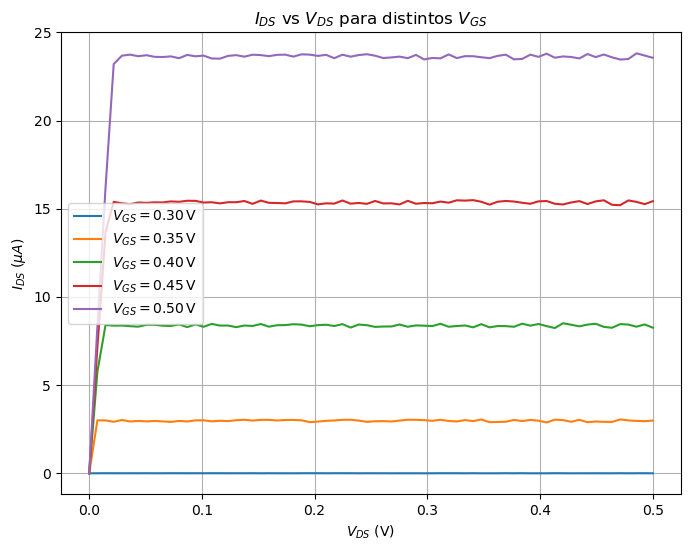

In [ ]:
### PLOT DEL EJERCICIO #####################

plt.figure(figsize=(8,6))

for i, VGS in enumerate(VGS_array):
    plt.plot(VDS_array, IDS_total[i]*10**6, label=rf"$V_{{GS}}={VGS:.2f}\,$V")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ $(\mu A)$")
plt.title(r"$I_{DS}$ vs $V_{DS}$ para distintos $V_{GS}$")
plt.grid(True)
#plt.xticks(np.arange(min(VDS_array), max(VDS_array) + 0.01, 0.01))
plt.legend()
plt.show()

In [7]:
### CÓDIGO EJERCICIO 4  T=298 ################################



T=298
KT = 0.026*T/300    #eV

#Capacidad total
CES = Cg + Cs + Cd
#Calculo numero de electrones en equilibrio

mu_s0 = Ef0
mu_d0 = Ef0
U0 = 0.0
Emin0 = min((Ec_modes_0), mu_s0, mu_d0) - 0.2
Emax0 = max((Ec_modes_0), mu_s0, mu_d0) + 0.2
E = np.linspace(Emin0, Emax0, numpasosE)

integrando_N = np.array([funcion_N(energia, Ec_modes_0, U0, mu_s0, mu_d0) for energia in E])
num_e0 = np.trapezoid(integrando_N, E)


#Ahora hago el bucle total igual que antes, pero le metro otro para la autoconsistencia.
IDS_total = []

for VGS in VGS_array:
    
    IDS_VDS = []
    
    for VDS in VDS_array:
        
        mu_s = Ef0
        mu_d = Ef0 - VDS
        Ec_eff = Ec_modes_0 #Ya tengo en cuenta el efecto de U, lo uso ahora solo por notacion

        Emin = min(np.min(Ec_eff), mu_d, mu_s) - 0.2
        Emax = max(np.max(Ec_eff), mu_d, mu_s) + 0.2
        E = np.linspace(Emin, Emax, numpasosE)
        
        #Semilla sin tener en cuenta el charging
        U_old = VGS*Cg/CES + VDS*Cd/CES

        error = 1.0
        numiteracion = 0

        while error > tolerancia and numiteracion < maxiteracion:
            
        
            # Cálculo de N con el U actual
            integrando_N = np.array([funcion_N(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
            num_e = np.trapezoid(integrando_N, E)
            
            
            #Calculo el nuevo valor de U teórico
            U_aux = VGS*Cg/CES + VDS*Cd/CES - q/(CES*1e-18) * (num_e - num_e0)
            #Le meto el alfa igual que en la relación 3 y calculo el nuevo valor de U
            U_new = U_old + alfa*(U_aux - U_old)
            #error para ver si ha convergido suficiente
            error = np.abs(U_new - U_old)
            U_old = U_new
            numiteracion += 1

        # Corriente con U convergido
        integrando_I = np.array([funcion_I(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
        i_aux = np.trapezoid(integrando_I, E)
        #Salimos del bucle y meto la intensidad de Vds
        IDS_VDS.append(i_aux)
    #Salimos del bucle y meto la curva de intensidad para un VGS
    IDS_total.append(IDS_VDS)
    print(f"{VGS} hecho")
    
#Lo pongo como np para que tarde menos en plotear
IDS_total = np.array(IDS_total, dtype=float)

0.3 hecho
0.35 hecho
0.4 hecho
0.45 hecho
0.5 hecho


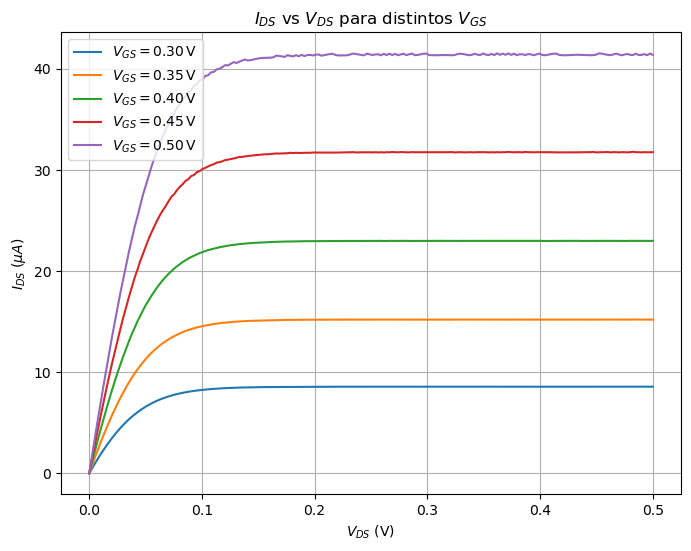

In [8]:
### PLOT DEL EJERCICIO #####################

plt.figure(figsize=(8,6))

for i, VGS in enumerate(VGS_array):
    plt.plot(VDS_array, IDS_total[i]*10**6, label=rf"$V_{{GS}}={VGS:.2f}\,$V")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ $(\mu A)$")
plt.title(r"$I_{DS}$ vs $V_{DS}$ para distintos $V_{GS}$")
plt.grid(True)
plt.legend()
plt.show()

Ahora comparamos la solución analítica con nuestros resultados para la región lineal y de saturación. Solo podemos comparar para T=0 porque suponemos que las funciones de fermi son escalones. Por tanto los resultados de T=298 no pueden tenerse en cuenta.

Recordamos que para la región lineal tenemos
$$
I = \frac{qW}{\pi^2\hbar^2}\sqrt{8m/9}(\eta q)^{3/2}\left((V_{GS}-V_T)^{3/2} - (V_{GS}-V_T-V_{DS}/\eta)^{3/2}\right)
$$

Y para la región de saturación

$$
I = \frac{qW}{\pi^2\hbar^2}\sqrt{8m/9}(\eta q)^{3/2}(V_{GS}-V_T)^{3/2}
$$




Calculamos analíticamente $V_T= \frac{Ec-\mu_s}{q \eta_0}$ = 0.3 V. Como podemos ver para T=0K la curva correspondiente a VGS=0.3V tiene intensidad nula, pero a una mayor ya sí tenemos intensidad.

Comprobamos ahora la saturación que es más fácil ya que son constantes. Para un Vgs y un Vds dado nos debe dar una intensidad. El factor $\frac{qW}{\pi^2\hbar^2}\sqrt{8m/9}q^{3/2}$ vale $0.007119$ $\frac{1}{\Omega}$.

Calculo $\eta$ que con nuestros datos es 

$$\eta = \frac{C_g}{C_{ES} + \frac{1}{2}q^2\frac{mWL}{\pi\hbar^2}}=0.11109$$

Por tanto en la región de saturación para $V_{GS}=0.5 V$ debe valer 0.000023578 A = 23.578 $\mu A$, que es muy próximo a lo que encontramos.
Para $V_{GS}=0.4 V$ encontramos I= 8.336 $\mu A$, de nuevo un resultado que vemos en el plot.

Por tanto podemos concluir que para la región de saturación la respuesta analítica es perfecta.


Nos vamos ahora a la región lineal. Para esto vemos que VDS no puede tomar muchos valores. Calculamos cuál es el máximo sabiendo que $V_{DS}/\eta = V_{GS}-V_T$ Para el más facil de ver, $V_{GS}=0.5V$ tenemos que $V_{DS}=0.022218 V$.

Pues fijamos VDS a 0.01 V y vemos qué pasa.
Para VGS=0.5, I=13.96 $\mu A$.
Para VGS=0.45, I=11.44 $\mu A$.
Para VGS=0.4, I= 8.07 $\mu A$..

Creo de nuevo el programa para T=0 con un zoom desde 0 a 0.1 V en VDS.

In [9]:
### APARTADO B ################################

T=0
KT = 0.026*T/300    #eV

tolerancia = 1e-5
alfa = 0.005
maxiteracion = 100
numpasosE=3000
VDS_array = np.linspace(0, 0.05, 120)

#Capacidad total
CES = Cg + Cs + Cd
#Calculo numero de electrones en equilibrio

mu_s0 = Ef0
mu_d0 = Ef0
U0 = 0.0
Emin0 = min((Ec_modes_0), mu_s0, mu_d0) - 0.2
Emax0 = max((Ec_modes_0), mu_s0, mu_d0) + 0.2
E = np.linspace(Emin0, Emax0, numpasosE)

integrando_N = np.array([funcion_N(energia, Ec_modes_0, U0, mu_s0, mu_d0) for energia in E])
num_e0 = np.trapz(integrando_N, E)


#Ahora hago el bucle total igual que antes, pero le metro otro para la autoconsistencia.
IDS_total = []

for VGS in VGS_array:
    
    IDS_VDS = []
    
    for VDS in VDS_array:
        
        mu_s = Ef0
        mu_d = Ef0 - VDS
        Ec_eff = Ec_modes_0 #Ya tengo en cuenta el efecto de U, lo uso ahora solo por notacion

        Emin = min(np.min(Ec_eff), mu_d, mu_s) - 0.2
        Emax = max(np.max(Ec_eff), mu_d, mu_s) + 0.2
        E = np.linspace(Emin, Emax, numpasosE)
        
        #Semilla sin tener en cuenta el charging
        U_old = VGS*Cg/CES + VDS*Cd/CES

        error = 1.0
        numiteracion = 0

        while error > tolerancia and numiteracion < maxiteracion:
            
        
            # Cálculo de N con el U actual
            integrando_N = np.array([funcion_N(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
            num_e = np.trapz(integrando_N, E)
            
            
            #Calculo el nuevo valor de U teórico
            U_aux = VGS*Cg/CES + VDS*Cd/CES - q/(CES*1e-18) * (num_e - num_e0)
            #Le meto el alfa igual que en la relación 3 y calculo el nuevo valor de U
            U_new = U_old + alfa*(U_aux - U_old)
            #error para ver si ha convergido suficiente
            error = np.abs(U_new - U_old)
            U_old = U_new
            numiteracion += 1

        # Corriente con U convergido
        integrando_I = np.array([funcion_I(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
        i_aux = np.trapz(integrando_I, E)
        #Salimos del bucle y meto la intensidad de Vds
        IDS_VDS.append(i_aux)
    #Salimos del bucle y meto la curva de intensidad para un VGS
    IDS_total.append(IDS_VDS)
    print(f"{VGS} hecho")
    
#Lo pongo como np para que tarde menos en plotear
IDS_total = np.array(IDS_total, dtype=float)

C:\Users\diego\AppData\Local\Temp\ipykernel_1172\3711610097.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num_e0 = np.trapz(integrando_N, E)
C:\Users\diego\AppData\Local\Temp\ipykernel_1172\3711610097.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num_e = np.trapz(integrando_N, E)
C:\Users\diego\AppData\Local\Temp\ipykernel_1172\3711610097.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  i_aux = np.trapz(integrando_I, E)


0.3 hecho
0.35 hecho
0.4 hecho
0.45 hecho
0.5 hecho


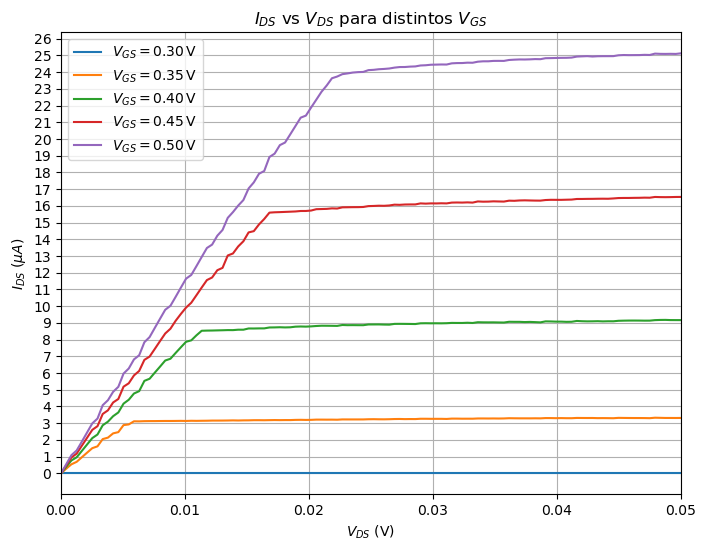

In [10]:
### PLOT DEL ZOOM #############

plt.figure(figsize=(8,6))

for i, VGS in enumerate(VGS_array):
    plt.plot(VDS_array, IDS_total[i]*10**6, label=rf"$V_{{GS}}={VGS:.2f}\,$V")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ $(\mu A)$")
plt.title(r"$I_{DS}$ vs $V_{DS}$ para distintos $V_{GS}$")
plt.grid(True)
plt.xlim(0, 0.05)
plt.yticks(np.arange(0, np.max(IDS_total*10**6) + 1, 1))
plt.legend()
plt.show()

Así grosso modo podemos ver los siguientes datos (para $V_{DS}$ = 0.01 V) que:
- VGS=0.35 V ya hemos alcanzado saturación.
- VGS=0.4 V tenemos que vale aproximadamente I = 8 $\mu A$ (<8.07)
- VGS=0.45 V tenemos I=10 $\mu A$ (<11.44)
- VGS=0.5 V tenemos que I=12 $\mu A$ (<13.96)

Como vemos todos estos valores se quedan un poquito por debajo de lo analítico. Para 0.4V es casi inapreciable pero para VGS=0.5V la diferencia ya es de 2 microA.

También tras hacer este zoom nos damos cuenta como la saturación no es verdaderamente una horizontal, sino que crece hasta un microA o varios. Este error puede ser numérico pero su acumulación nos cuenta lo contrario, otra discrepancia con lo analítico

In [6]:
### Apartado C #####

T = 298
KT = 0.026*T/300    # eV


#Ahora voy hasta 1V porque inicialmente lo puse en 5V y saturaba mucho antes.
VGS_array = np.linspace(0.0, 1.0, 100)
VDS = 0.5 #Fijo el VDS

CES = Cg + Cs + Cd


#Cambio los parámetros porque tarda mucho menos
numpasosE = 4000
maxiteracion = 200
alfa = 0.05

#Electrones en equilibrio
mu_s0 = Ef0
mu_d0 = Ef0
U0 = 0.0

#Esto lo hacía antes dentro del bucle, ahora lo pongo fuera. Amplío la energía mínima y máxima en +1
Emin0 = min(np.min(Ec_modes_0), mu_s0, mu_d0) - 1.0
Emax0 = max(np.max(Ec_modes_0), mu_s0, mu_d0) + 1.0
E = np.linspace(Emin0, Emax0, numpasosE)

integrando_N = np.array([funcion_N(energia, Ec_modes_0, U0, mu_s0, mu_d0) for energia in E])
num_e0 = np.trapezoid(integrando_N, E)

IDS_total = []

#Solo barro en VGS no en VDS.

for VGS in VGS_array:
    
    mu_s = Ef0
    mu_d = Ef0 - VDS
    Ec_eff = Ec_modes_0

    Emin = min(np.min(Ec_eff) - 1.0, mu_d, mu_s) - 0.2
    Emax = max(np.max(Ec_eff) + 1.0, mu_d, mu_s) + 0.2
    E = np.linspace(Emin, Emax, numpasosE)

    U_old = VGS*Cg/CES + VDS*Cd/CES

    error = 1.0
    numiteracion = 0

    while error > tolerancia and numiteracion < maxiteracion:

        integrando_N = np.array([funcion_N(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
        num_e = np.trapezoid(integrando_N, E)

        U_aux = VGS*Cg/CES + VDS*Cd/CES - q/(CES) * (num_e - num_e0)

        U_new = U_old + alfa*(U_aux - U_old)

        error = np.abs(U_new - U_old)
        U_old = U_new
        numiteracion += 1

    integrando_I = np.array([funcion_I(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
    i_aux = np.trapezoid(integrando_I, E)

    IDS_total.append(i_aux)

    print(f"{VGS} hecho, I = {i_aux:.10f}")

IDS_total = np.array(IDS_total)

0.0 hecho, I = 0.0000000004
0.010101010101010102 hecho, I = 0.0000000005
0.020202020202020204 hecho, I = 0.0000000008
0.030303030303030304 hecho, I = 0.0000000011
0.04040404040404041 hecho, I = 0.0000000017
0.05050505050505051 hecho, I = 0.0000000025
0.06060606060606061 hecho, I = 0.0000000037
0.07070707070707072 hecho, I = 0.0000000055
0.08080808080808081 hecho, I = 0.0000000081
0.09090909090909091 hecho, I = 0.0000000120
0.10101010101010102 hecho, I = 0.0000000178
0.11111111111111112 hecho, I = 0.0000000263
0.12121212121212122 hecho, I = 0.0000000388
0.13131313131313133 hecho, I = 0.0000000574
0.14141414141414144 hecho, I = 0.0000000849
0.15151515151515152 hecho, I = 0.0000001253
0.16161616161616163 hecho, I = 0.0000001853
0.17171717171717174 hecho, I = 0.0000002738
0.18181818181818182 hecho, I = 0.0000004045
0.19191919191919193 hecho, I = 0.0000005971
0.20202020202020204 hecho, I = 0.0000008805
0.21212121212121213 hecho, I = 0.0000012959
0.22222222222222224 hecho, I = 0.0000019065
0

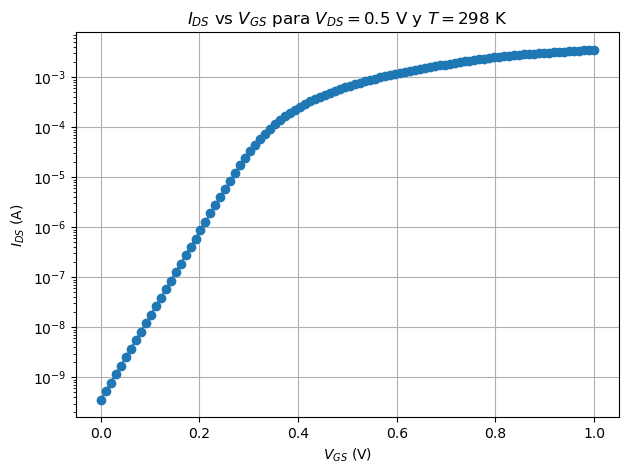

In [ ]:
### PLOT log I- VGS ##############################

plt.figure(figsize=(7,5))
plt.semilogy(VGS_array, np.abs(IDS_total), 'o-')

plt.xlabel(r'$V_{GS}$ (V)')
plt.ylabel(r'$I_{DS}$ (A)')
plt.title(r'$I_{DS}$ vs $V_{GS}$ para $V_{DS}=0.5$ V y $T=298$ K')
plt.grid(True)

plt.show()

In [8]:
### PENDIENTE SUBUMBRAL ###############


#Pongo los límites que hay hasta que se vea recto. V1 es el mínimo y V2 el máximo
V1 = 0.05 
V2 = 0.25

#Cojo dichos puntos, modo máscara
buenos = (VGS_array > V1) & (VGS_array < V2) & (IDS_total > 0)

#Modifico los arrays para que tengan solo esos puntos y lo pongo en lgaritmo la intensidad.
x = VGS_array[buenos]
y = np.log10(IDS_total[buenos])

coef = np.polyfit(x, y, 1)

#Me interesa la pendiente pero S es la inversa. Lo calculo y lo imprimo.
pendiente = coef[0]
S = 1/pendiente

print("Pendiente =", pendiente, "dec/V")
print("S =", S, "V/dec")
print("S =", S*1000, "mV/dec")

Pendiente = 16.760727006502048 dec/V
S = 0.059663283079073266 V/dec
S = 59.66328307907327 mV/dec


**Apartado d:** 

Yo aquí creo que el nuevo valor para $V_T$ es uno aproximado, que nos dé una idea de la escala a la que ya sí hay corriente. Como nos movemos en el régimen de microamperios no puedo poner nada entre 0 y 0.2 V. Así que pondré mi límite V2 para ello. A partir de unos 0.25V tenemos ya $10^{-5}$ A, osea decenas de microamperios, que sí podemos medir con mayor facilidad. Recordemos también que para el apartado A obtuvimos que a T=298K y VDS=0.5 la curva de VGS tenía un pico de saturación de unos 42 microamperios, así que una medida de dicha magnitud es la que necesitamos. 

### Ejercicio 5:

**Calcular curva I-V para un transistor MOSFET en transporte semiclásico para $V_{DS}$ entre 0 y 0.5V y $V_{GS}=0.5V$**

In [ ]:
### FUNCIONES Y PARÁMETROS PARA EL EJERCICIO 5 #######################


movilidad = 300 #cm^2/Vs
VT = 0.3     #V
L=40 *10**(-9) #m
W= 3*L       #m
Cd=0.0
Cs=0.0
Cg=0.1 *10**(-15) #F

def funcion_I_mosfet(mu_aux, vds_aux, vgs_aux, vt_aux):
    
    #Por si está off
    if vgs_aux<vt_aux:
        return 0
    #Para la región lineal: (pongo el = aquí porque deben ser continuas)
    elif vds_aux <= (vgs_aux-vt_aux):
        return mu_aux*Cg/(L**2)*((vgs_aux-vt_aux)*vds_aux-vds_aux**2/2)
    #Para la región de saturación:
    elif vds_aux > (vgs_aux-vt_aux):
        return mu_aux*Cg/(2*L**2)*(vgs_aux-vt_aux)**2
        

In [87]:
### CÓDIGO EJERCICIO 5 TRANSPORTE CLÁSICO ############################

T = 0
KT = 0.026*T/300    #eV

#Capacidad total

CES = Cg + Cs + Cd
VDS_array = np.linspace(0, 0.5, 200)

#Convierto la movilidad en mis unidades (SI)
movilidad_SI = movilidad*10**(-4) #m^2/Vs


IDS_total = []
for VGS in VGS_array:
    IDS_VDS=[]
    for VDS in VDS_array:
        
        intensidad = funcion_I_mosfet(movilidad_SI, VDS, VGS, VT)
        IDS_VDS.append(intensidad)
    IDS_total.append(IDS_VDS)
    print(f"{VGS} hecho")
    

IDS_total = np.array(IDS_total, dtype=float)


0.3 hecho
0.35 hecho
0.4 hecho
0.45 hecho
0.5 hecho


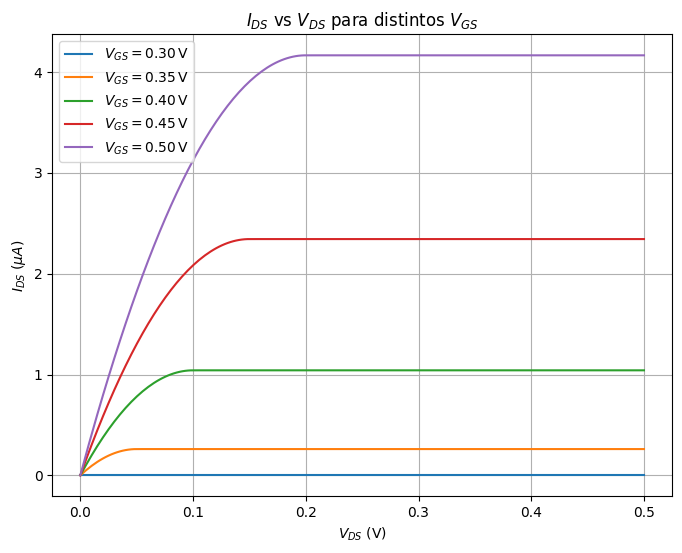

In [88]:
### PLOT DEL EJERCICIO #####################

plt.figure(figsize=(8,6))

for i, VGS in enumerate(VGS_array):
    plt.plot(VDS_array, IDS_total[i]*10**6, label=rf"$V_{{GS}}={VGS:.2f}\,$V")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ $(\mu A)$")
plt.title(r"$I_{DS}$ vs $V_{DS}$ para distintos $V_{GS}$")
plt.grid(True)
plt.legend()
plt.show()

Los resultados están un poco desfasados con la solución. Si en lugar de poner en la definición de la intensidad dividiendo / L^2 sustituímos esa L por la W, nos da exactamente el resultado. Creo que Marc Baldo se ha equivocado en eso.

In [96]:
### Definición de parámetros para el ejercicio 2 ############################

T = 1               #K
KT = 0.026*T/300    #eV
L = 40             #nm
W = 3*L             #nm
Ef0 = -5.0          #eV
m=0.5*m0

mu_s0 = Ef0     
mu_d0 = Ef0

G0 = 2 * q / h   # A/V #ya trabajo en unidades naturales asi que no me hace falta el q^2 sino solo q

Cs = 0.0
Cd = 0.0
Cg = 100.0         #aF/nm
CES = (Cs+Cd+Cg)


tolerancia = 1e-5
alfa = 0.005
maxiteracion = 100

#Creo el vector de voltajes y las energías

VGS_array = [0.30, 0.35, 0.40, 0.45, 0.50]
VDS_array = np.linspace(0, 0.5, 100)
Ec_modes_0 = -4.7  #eV
numpasosE=1000  #Si pones menos de 3000 las curvas salen woobly, salen no rectas.



In [105]:
### CÓDIGO EJERCICIO 5 CON CQ PARA INFINITO ################################

T=298
KT = 0.026*T/300    #eV

VT=0.3  #V

    
def funcion_I_ej5(energia, Ec_aux, U, mus, mud):

    if energia + U > Ec_aux:
        
        cte = W*1e-9/(np.pi**2*hbar**2)*np.sqrt(2*m*q)
        func = cte*np.sqrt(energia)*(fermi(energia,mus)-fermi(energia,mud))
        return func
    else:
        return 0.0

#Capacidad total
CES = Cg + Cs + Cd
#Calculo numero de electrones en equilibrio

mu_s0 = Ef0
mu_d0 = Ef0
U0 = 0.0
Emin0 = min((Ec_modes_0), mu_s0, mu_d0) - 0.2
Emax0 = max((Ec_modes_0), mu_s0, mu_d0) + 0.2
E = np.linspace(Emin0, Emax0, numpasosE)

integrando_N = np.array([funcion_N(energia, Ec_modes_0, U0, mu_s0, mu_d0) for energia in E])
num_e0 = np.trapz(integrando_N, E)


#Ahora hago el bucle total igual que antes, pero le metro otro para la autoconsistencia.
IDS_total = []

for VGS in VGS_array:
    
    IDS_VDS = []
    
    for VDS in VDS_array:
        
        mu_s = Ef0
        mu_d = Ef0 - VDS
        Ec_eff = Ec_modes_0 #Ya tengo en cuenta el efecto de U, lo uso ahora solo por notacion

        Emin = min(np.min(Ec_eff), mu_d, mu_s) - 0.2
        Emax = max(np.max(Ec_eff), mu_d, mu_s) + 0.2
        E = np.linspace(Emin, Emax, numpasosE)
        
        #Semilla sin tener en cuenta el charging
        if VGS < VT:
            U_old = VGS*Cg/CES + VDS*Cd/CES
        else:
             U_old = VT*Cg/CES + VDS*Cd/CES
       

        # Corriente con U convergido
        integrando_I = np.array([funcion_I_ej5(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
        i_aux = np.trapz(integrando_I, E)
        #Salimos del bucle y meto la intensidad de Vds
        IDS_VDS.append(i_aux)
    #Salimos del bucle y meto la curva de intensidad para un VGS
    IDS_total.append(IDS_VDS)
    print(f"{VGS} hecho")
    
#Lo pongo como np para que tarde menos en plotear
IDS_total = np.array(IDS_total, dtype=float)

C:\Users\diego\AppData\Local\Temp\ipykernel_14376\2885257660.py:14: RuntimeWarning: invalid value encountered in sqrt
  func = cte*np.sqrt(energia)*(fermi(energia,mus)-fermi(energia,mud))


0.3 hecho
0.35 hecho
0.4 hecho
0.45 hecho
0.5 hecho


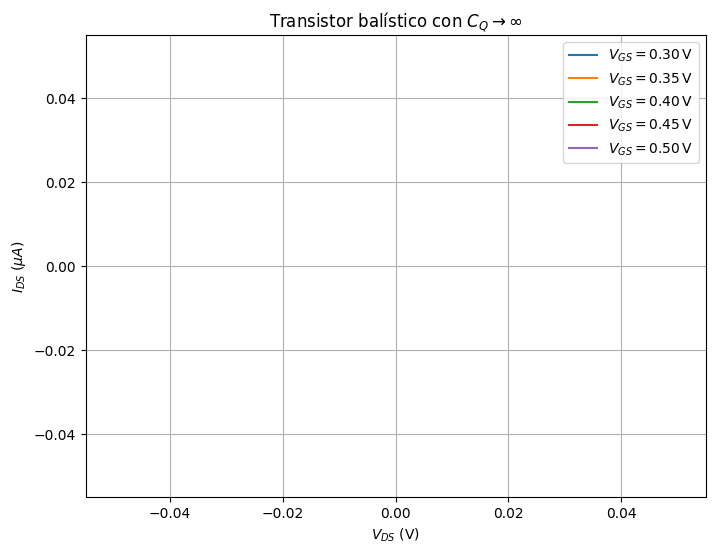

In [106]:
### PLOT ###############################################################

plt.figure(figsize=(8,6))

for i, VGS in enumerate(VGS_array):
    plt.plot(VDS_array, IDS_total[i]*1e6, label=rf"$V_{{GS}}={VGS:.2f}\,$V")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ $(\mu A)$")
plt.title(r"Transistor balístico con $C_Q \to \infty$")
plt.grid(True)
plt.legend()
plt.show()

In [112]:
### CÓDIGO CON CQ INFINITO (NO AUTOCONSISTENCIA) #######

T = 298
KT = 0.026*T/300    # eV

VDS_array = np.linspace(0, 0.5, 200)

def funcion_I(energia, Ec_aux, U, mus, mud):

    if energia + U > Ec_aux:
        
        cte = W*1e-9/(np.pi**2*hbar**2)*np.sqrt(2*m*q)
        func = cte*np.sqrt(energia-Ec_aux+U)*(fermi(energia,mus)-fermi(energia,mud))
        return func
    else:
        return 0.0

IDS_total = []

for VGS in VGS_array:
    
    IDS_VDS = []
    
    for VDS in VDS_array:
        
        mu_s = Ef0
        mu_d = Ef0 - VDS
        
        Emin = min(Ec_eff, mu_d, mu_s) - 0.2
        Emax = max(Ec_eff, mu_d, mu_s) + 0.2
        
        E = np.linspace(Emin, Emax, numpasosE)
        
        # No hay autoconsistencia
        if VGS < VT:
            U_old = VGS*Cg/CES
        else:
            U_old = VT*Cg/CES
        
        integrando_I = np.array([funcion_I(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
        intensidad = np.trapz(integrando_I, E)
        
        IDS_VDS.append(intensidad)
        
    IDS_total.append(IDS_VDS)
    print(f"{VGS} hecho")

IDS_total = np.array(IDS_total, dtype=float)




0.3 hecho
0.35 hecho
0.4 hecho
0.45 hecho
0.5 hecho


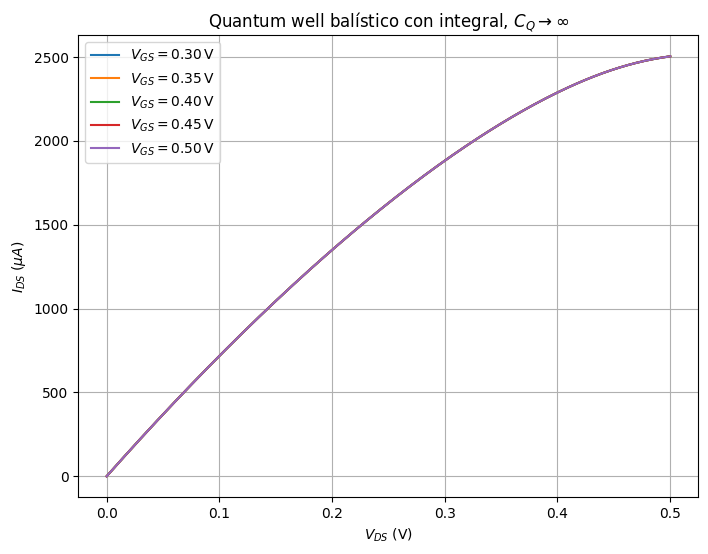

In [113]:
### PLOT ###############################################################

plt.figure(figsize=(8,6))

for i, VGS in enumerate(VGS_array):
    plt.plot(VDS_array, IDS_total[i]*1e6, label=rf"$V_{{GS}}={VGS:.2f}\,$V")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ $(\mu A)$")
plt.title(r"Quantum well balístico con integral, $C_Q \to \infty$")
plt.grid(True)
plt.legend()
plt.show()